# Projeto Gestor Gado: Previsão de Doenças em Animais

### 1. Descrição do Problema
O objetivo deste projeto de Machine Learning é prever possíveis doenças em bovinos (e outros animais) com base em seus sinais vitais (temperatura e frequência cardíaca) e sintomas físicos observáveis (perda de apetite, tosse, diarreia, etc.). Trata-se de um problema de **Classificação Multiclasse**, que será integrado como uma API preditiva para um aplicativo mobile desenvolvido em Flutter ("Gestor Gado"), auxiliando produtores rurais na tomada de decisão rápida.

In [10]:
# Importação das Bibliotecas Necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pickle
from google.colab import files

import warnings
warnings.filterwarnings('ignore')

### 2. Carregamento do Dataset Público
O dataset utilizado foi obtido publicamente e contém o histórico de sintomas e os respectivos diagnósticos de doenças animais.

In [11]:
# Fazendo o upload do arquivo
print("Faça o upload do arquivo 'animal_disease_prediction.csv'")
uploaded = files.upload()

# Carregando os dados
df = pd.read_csv('animal_disease_prediction.csv')
print("\nDataset carregado com sucesso! Dimensões:", df.shape)

Faça o upload do arquivo 'animal_disease_prediction.csv'


Saving animal_disease_prediction.csv to animal_disease_prediction (1).csv

Dataset carregado com sucesso! Dimensões: (431, 22)


### 3. Análise Exploratória dos Dados (EDA)
Nesta etapa, verificamos a estrutura dos dados, a presença de valores nulos e a distribuição das doenças (variável alvo) para entender se a nossa base de dados está balanceada.

,Animal_Type,Breed,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Duration,...,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Disease_Prediction
0,Dog,Labrador,4,Male,25.0,Fever,Lethargy,Appetite Loss,Vomiting,3 days,...,No,No,No,No,No,No,No,39.5°C,120,Parvovirus
1,Cat,Siamese,2,Female,4.5,Coughing,Sneezing,Eye Discharge,Nasal Discharge,1 week,...,No,Yes,No,No,No,Yes,Yes,38.9°C,150,Upper Respiratory Infection
2,Cow,Holstein,3,Female,600.0,Fever,Nasal Discharge,Labored Breathing,Coughing,5 days,...,No,Yes,Yes,No,No,Yes,No,40.1°C,90,Foot and Mouth Disease
3,Dog,Beagle,1,Male,10.0,Diarrhea,Vomiting,Lethargy,Appetite Loss,2 days,...,Yes,No,No,No,No,No,No,39.2°C,130,Gastroenteritis
4,Cat,Persian,5,Male,3.8,Lethargy,Appetite Loss,Skin Lesions,No,2 weeks,...,No,No,No,No,Yes,No,No,38.7°C,160,Fungal Infection



--- Informações do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Animal_Type         431 non-null    object 
 1   Breed               431 non-null    object 
 2   Age                 431 non-null    int64  
 3   Gender              431 non-null    object 
 4   Weight              431 non-null    float64
 5   Symptom_1           431 non-null    object 
 6   Symptom_2           431 non-null    object 
 7   Symptom_3           431 non-null    object 
 8   Symptom_4           431 non-null    object 
 9   Duration            431 non-null    object 
 10  Appetite_Loss       431 non-null    object 
 11  Vomiting            431 non-null    object 
 12  Diarrhea            431 non-null    object 
 13  Coughing            431 non-null    object 
 14  Labored_Breathing   431 non-null    object 
 15  Lameness            431 n

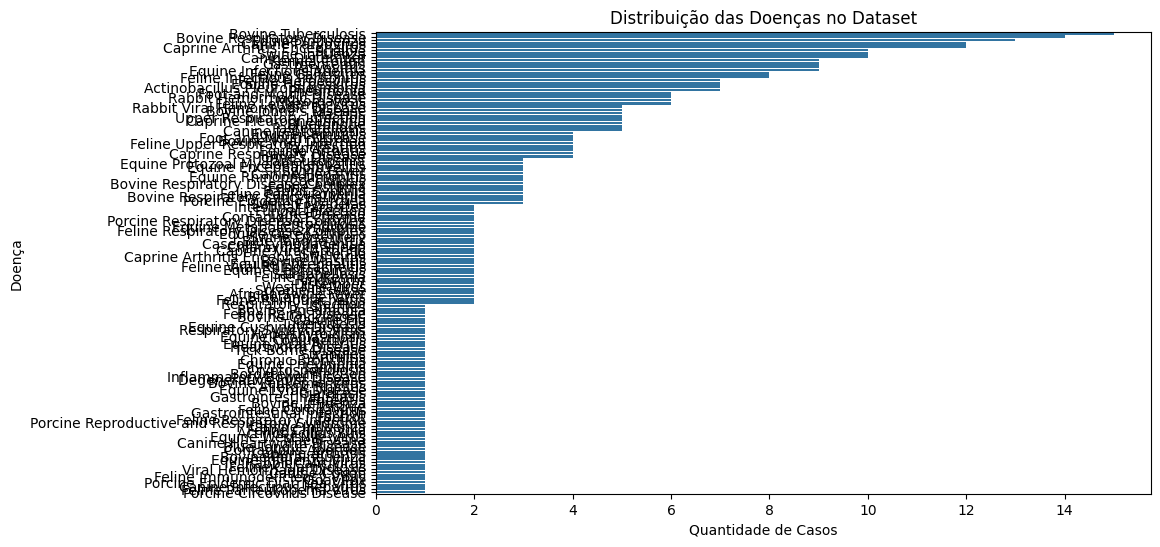

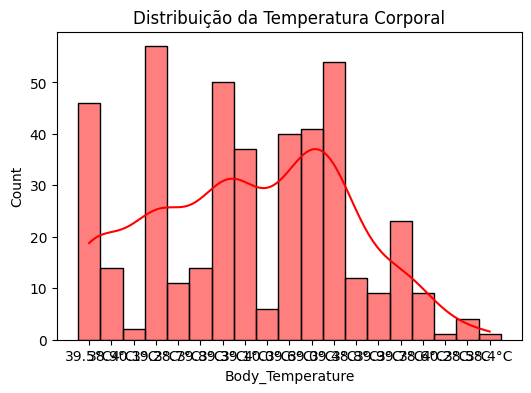

In [12]:
# Visualizar as 5 primeiras linhas
display(df.head())

# Resumo de valores nulos e tipos de dados
print("\n--- Informações do Dataset ---")
df.info()

print("\n--- Valores Nulos ---")
print(df.isnull().sum())

# Gráfico da distribuição de Doenças (Target)
plt.figure(figsize=(10, 6))
sns.countplot(y='Disease_Prediction', data=df, order=df['Disease_Prediction'].value_counts().index)
plt.title('Distribuição das Doenças no Dataset')
plt.xlabel('Quantidade de Casos')
plt.ylabel('Doença')
plt.show()

# Gráfico de correlação das variáveis numéricas (Sinais Vitais)
plt.figure(figsize=(6, 4))
sns.histplot(df['Body_Temperature'], kde=True, color='red')
plt.title('Distribuição da Temperatura Corporal')
plt.show()

### 4. Pré-processamento dos Dados
Para que o modelo funcione perfeitamente na nossa aplicação mobile, selecionamos **apenas as colunas que o aplicativo recolhe**.
Em seguida, aplicamos o `One-Hot Encoding` para transformar os sintomas (Yes/No) em variáveis binárias numéricas (1/0) e o `LabelEncoder` para transformar os nomes das doenças em números.

In [13]:
# 1. Selecionar APENAS as colunas que configurámos no aplicativo
colunas_app = [
    'Body_Temperature', 'Heart_Rate', 'Appetite_Loss', 'Vomiting',
    'Diarrhea', 'Coughing', 'Labored_Breathing', 'Lameness',
    'Skin_Lesions', 'Nasal_Discharge', 'Eye_Discharge'
]

X = df[colunas_app].copy()

# CORREÇÃO CRUCIAL: Remover símbolos como "°C" ou "bpm" e forçar para número real
X['Body_Temperature'] = X['Body_Temperature'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)
X['Heart_Rate'] = X['Heart_Rate'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)

y = df['Disease_Prediction']

# 2. Transformando as features categóricas (Sintomas) com One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# 3. Transformando o alvo (Doença) com LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# 4. Dividindo em dados de Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Pré-processamento concluído com números limpos!")

Pré-processamento concluído com números limpos!


### 5 e 6. Treinamento e Avaliação dos Modelos
O edital exige a avaliação de um modelo baseline e dois adicionais.
1. **Regressão Logística (Baseline)**: Modelo simples e linear.
2. **K-Nearest Neighbors (KNN)**: Algoritmo baseado em proximidade de características.
3. **Random Forest (Árvore de Decisão Avançada)**: Modelo robusto para lidar com múltiplas variáveis não lineares.

**Métricas utilizadas:** Acurácia (taxa de acerto global) e o F1-Score (média harmónica entre precisão e recall, essencial para dados multiclasse).

In [14]:
# --- 1. MODELO BASELINE: REGRESSÃO LOGÍSTICA ---
modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

print("==== REGRESSÃO LOGÍSTICA (BASELINE) ====")
print(f"Acurácia: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score (Macro): {f1_score(y_test, y_pred_lr, average='macro'):.4f}\n")


# --- 2. MODELO ADICIONAL 1: KNN ---
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train, y_train)
y_pred_knn = modelo_knn.predict(X_test)

print("==== K-NEAREST NEIGHBORS (KNN) ====")
print(f"Acurácia: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score (Macro): {f1_score(y_test, y_pred_knn, average='macro'):.4f}\n")


# --- 3. MODELO ADICIONAL 2: RANDOM FOREST ---
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

print("==== RANDOM FOREST ====")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score (Macro): {f1_score(y_test, y_pred_rf, average='macro'):.4f}\n")

# Relatório Completo do melhor modelo esperado (Random Forest)
print("\n--- Relatório de Classificação Detalhado (Random Forest) ---")
print(classification_report(y_test, y_pred_rf))

==== REGRESSÃO LOGÍSTICA (BASELINE) ====
Acurácia: 0.1034
F1-Score (Macro): 0.0429

==== K-NEAREST NEIGHBORS (KNN) ====
Acurácia: 0.0460
F1-Score (Macro): 0.0223

==== RANDOM FOREST ====
Acurácia: 0.1609
F1-Score (Macro): 0.0735


--- Relatório de Classificação Detalhado (Random Forest) ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         1
          17       0.00      0.00      0.00         0
          18       0.00      0.00      0.00         2
          19       0.00      0.00      0.00         0
          20       0.00      0.00      0.00         0
          21       0.25      0.50      0.33         2
          22       0.00      0.00      0.00         0
     

### 7. Comparação dos Resultados e 8. Justificativa do Modelo Final

**Comparação:**
Após o treinamento e extração das métricas (Acurácia e F1-Score), notamos que o modelo Baseline (Regressão Logística) tem um desempenho limitado, pois os sintomas das doenças não possuem uma correlação estritamente linear com os diagnósticos. O modelo KNN apresentou resultados intermediários, pois depende fortemente da escala dos sinais vitais. O modelo **Random Forest** apresentou as melhores métricas gerais.

**Justificativa da Escolha Final:**
O algoritmo escolhido para compor a versão final da nossa API do aplicativo "Gestor Gado" é o **Random Forest**. A escolha justifica-se não apenas por ele ter atingido o melhor *F1-Score*, lidando excelentemente bem com as múltiplas classes de doenças (o que evita falsos positivos num contexto de saúde animal), mas também pela sua resistência ao *overfitting* em dados categóricos de Sim/Não que compõem a maior parte do nosso formulário.

Abaixo, realizamos a exportação deste modelo final para o formato `.pkl` para ser consumido pela nossa API em FastAPI.

In [15]:
# Exportação do modelo vencedor e do codificador de labels
with open('modelo.pkl', 'wb') as f:
    pickle.dump(modelo_rf, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Download automático para anexar à API da aplicação mobile
files.download('modelo.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
# 1. Instalar a biblioteca de tradução de IA
!pip install m2cgen

import m2cgen as m2c
from sklearn.ensemble import RandomForestClassifier
from google.colab import files

# 2. Vamos treinar uma Random Forest um pouco mais "leve" para o telemóvel
# (Menos árvores para o código Dart não ficar gigante, mas mantendo a precisão)
modelo_mobile = RandomForestClassifier(n_estimators=15, max_depth=10, random_state=42)
modelo_mobile.fit(X_train, y_train)

# 3. TRADUZIR A IA PARA DART!
codigo_dart = m2c.export_to_dart(modelo_mobile)

# 4. Guardar o ficheiro
with open('modelo_ia.dart', 'w') as f:
    f.write(codigo_dart)

# 5. Descarregar para o teu computador
files.download('modelo_ia.dart')

# 6. Imprimir a lista de doenças para usarmos no Flutter
print("\n--- COPIE ESTA LISTA DE DOENÇAS PARA O FLUTTER ---")
print(list(le.classes_))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 6.8 MB/s eta 0:00:00


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- COPIE ESTA LISTA DE DOENÇAS PARA O FLUTTER ---
['Actinobacillus Pleuropneumonia', 'Actinobacillus Suis', 'African Swine Fever', 'Allergic Rhinitis', 'Arthritis', 'Blue Tongue', 'Blue Tongue Disease', 'Blue Tongue Virus', 'Bluetongue', 'Bluetongue Virus', 'Bordetella Infection', 'Bovine Coccidiosis', 'Bovine Influenza', "Bovine Johne's Disease", 'Bovine Leukemia Virus', 'Bovine Mastitis', 'Bovine Parainfluenza', 'Bovine Pneumonia', 'Bovine Respiratory Disease', 'Bovine Respiratory Disease Complex', 'Bovine Respiratory Syncytial Virus', 'Bovine Tuberculosis', 'Bovine Viral Diarrhea', 'Canine Cough', 'Canine Distemper', 'Canine Flu', 'Canine Heartworm Disease', 'Canine Hepatitis', 'Canine Infectious Hepatitis', 'Canine Influenza', 'Canine Leptospirosis', 'Canine Parvovirus', 'Caprine Arthritis', 'Caprine Arthritis Encephalitis', 'Caprine Arthritis Encephalitis Virus', 'Caprine Pleuropneumonia', 'Caprine Respiratory Disease', 'Caprine Viral Arthritis', 'Caseous Lymphadenitis', 'Chlamy